In [1]:
!pip install split-folders

In [2]:
!pip install tensorflow

In [41]:
import os
dataset_path = r"C:\Users\Chourouk\Desktop\CNNunb\PlantVillage"

# Initialize total count
total_image_count = 0

# Traverse through each subdirectory
for subdir in os.listdir(dataset_path):
    # Construct full path to subdirectory
    subdir_path = os.path.join(dataset_path, subdir)
    
    # Check if it's a directory
    if os.path.isdir(subdir_path):
        # List files in the subdirectory
        image_files = [file for file in os.listdir(subdir_path) if file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]
        
        # Count images in this subdirectory
        num_images = len(image_files)
        
        # Increment total count
        total_image_count += num_images
        
        print(f"Number of images in {subdir}: {num_images}")

print("Total number of image files in the dataset:", total_image_count)

Number of images in Tomato_Bacterial_spot: 2127
Number of images in Tomato_Early_blight: 1000
Number of images in Tomato_healthy: 1591
Number of images in Tomato_Late_blight: 1909
Number of images in Tomato_Leaf_Mold: 952
Number of images in Tomato_Septoria_leaf_spot: 1771
Number of images in Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Number of images in Tomato__Target_Spot: 1404
Number of images in Tomato__Tomato_mosaic_virus: 373
Number of images in Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Total number of image files in the dataset: 16011


In [1]:
import os
import splitfolders

# Define the input dataset directory
dataset_path = "C:\\Users\\Chourouk\\Desktop\\AlexNetunb\\PlantVillage"

# Define the output directory where the split datasets will be created
output_path = "./dataset"

# Create the output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Define the ratios for the split (train:val:test)
ratios = (0.7, 0.1, 0.2)

# Perform the split
splitfolders.ratio(dataset_path, output=output_path, seed=1337, ratio=ratios, group_prefix=None, move=False)

Copying files: 16012 files [19:11, 13.90 files/s]


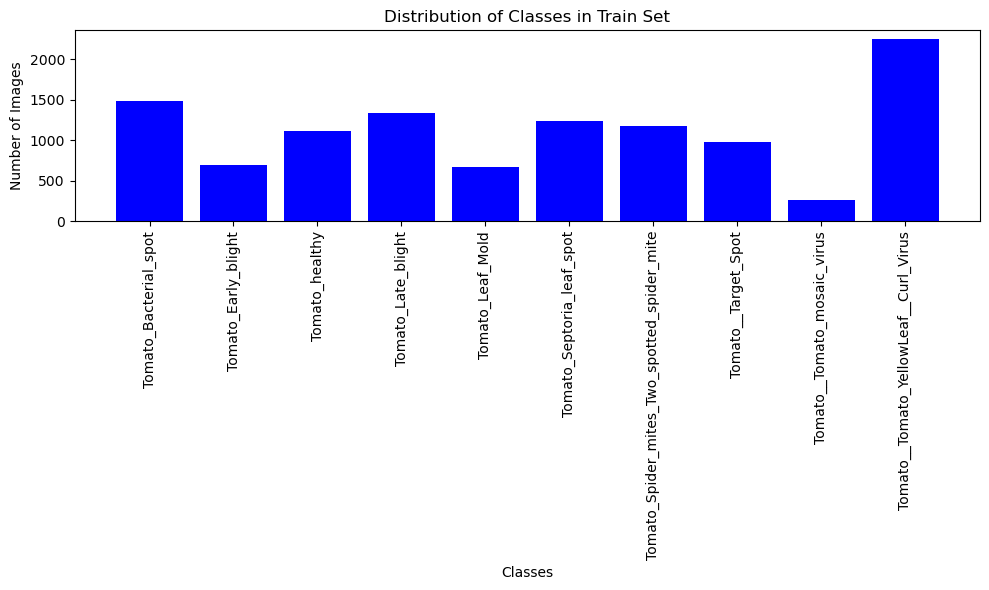

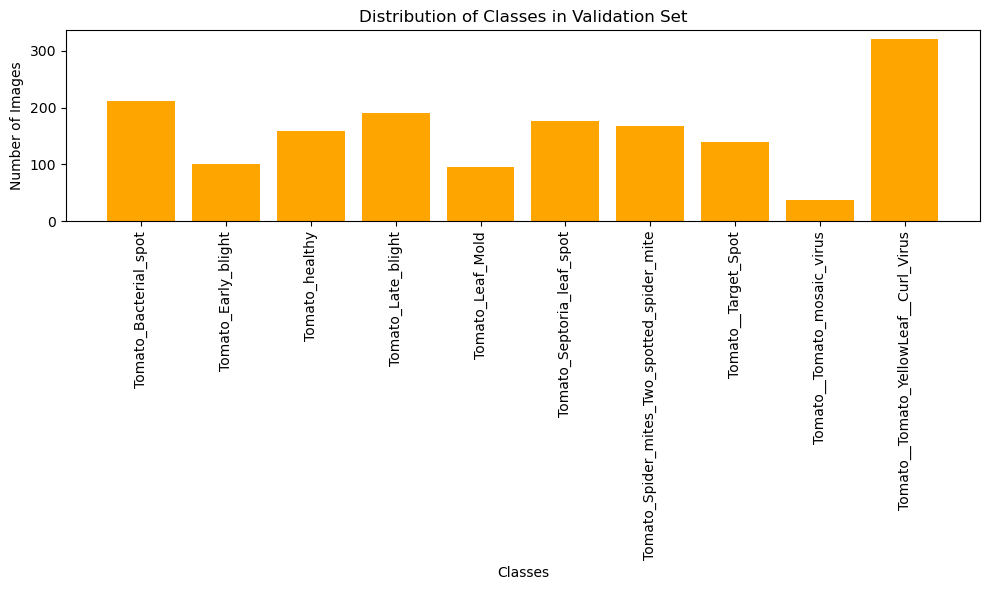

In [2]:
import os
import matplotlib.pyplot as plt

# Define the paths to the train and validation directories
train_path = os.path.join(output_path, 'train')
val_path = os.path.join(output_path, 'val')

# Function to count the number of images in each class
def count_images_in_classes(folder_path):
    classes_count = {}
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            classes_count[class_folder] = num_images
    return classes_count

# Count the number of images in each class for training and validation sets
train_classes_count = count_images_in_classes(train_path)
val_classes_count = count_images_in_classes(val_path)

# Plotting train distribution
plt.figure(figsize=(10, 6))
plt.bar(train_classes_count.keys(), train_classes_count.values(), color='blue')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Classes in Train Set')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plotting validation distribution
plt.figure(figsize=(10, 6))
plt.bar(val_classes_count.keys(), val_classes_count.values(), color='orange')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Classes in Validation Set')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# Initializing the CNN
classifier = Sequential()

# Convolution Step 1
classifier.add(Convolution2D(96, 11, strides = (4, 4), padding = 'valid', input_shape=(224, 224, 3), activation = 'relu'))

# Max Pooling Step 1
classifier.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'valid'))
classifier.add(BatchNormalization())

# Convolution Step 2
classifier.add(Convolution2D(256, 11, strides = (1, 1), padding='valid', activation = 'relu'))

# Max Pooling Step 2
classifier.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding='valid'))
classifier.add(BatchNormalization())

# Convolution Step 3
classifier.add(Convolution2D(384, 3, strides = (1, 1), padding='valid', activation = 'relu'))
classifier.add(BatchNormalization())

# Convolution Step 4
classifier.add(Convolution2D(384, 3, strides = (1, 1), padding='valid', activation = 'relu'))
classifier.add(BatchNormalization())

# Convolution Step 5
classifier.add(Convolution2D(256, 3, strides=(1,1), padding='valid', activation = 'relu'))

# Max Pooling Step 3
classifier.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'valid'))
classifier.add(BatchNormalization())

# Flattening Step
classifier.add(Flatten())

# Full Connection Step
classifier.add(Dense(units = 4096, activation = 'relu'))
classifier.add(Dropout(0.4))
classifier.add(BatchNormalization())
classifier.add(Dense(units = 4096, activation = 'relu'))
classifier.add(Dropout(0.4))
classifier.add(BatchNormalization())
classifier.add(Dense(units = 1000, activation = 'relu'))
classifier.add(Dropout(0.2))
classifier.add(BatchNormalization())
classifier.add(Dense(units = 38, activation = 'softmax'))
classifier.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 27, 27, 96)        0         
 g2D)                                                            
                                                                 
 batch_normalization_24 (Ba  (None, 27, 27, 96)        384       
 tchNormalization)                                               
                                                                 
 conv2d_16 (Conv2D)          (None, 17, 17, 256)       2973952   
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 8, 8, 256)         0         
 ng2D)                                                           
                                                      

In [17]:
# Load the pre-trained weights of AlexNet
classifier.load_weights(r"C:\Users\Chourouk\Desktop\AlexNetunb\best_weights_9.hdf5")

In [18]:
from tensorflow.keras.optimizers import Adam

# Replace the final dense layer for 38 classes
classifier.pop()  # Remove the last dense layer with 38 units

# Add new output layer for 10 classes
classifier.add(Dense(units=10, activation='softmax'))
classifier.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 27, 27, 96)        0         
 g2D)                                                            
                                                                 
 batch_normalization_24 (Ba  (None, 27, 27, 96)        384       
 tchNormalization)                                               
                                                                 
 conv2d_16 (Conv2D)          (None, 17, 17, 256)       2973952   
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 8, 8, 256)         0         
 ng2D)                                                           
                                                      

In [19]:
# we chose to train the top 2 conv blocks
# the first 8 layers and unfreeze the rest:
print("Freezed layers:")
for i, layer in enumerate(classifier.layers[:15]):
    print(i, layer.name)
    layer.trainable = False

Freezed layers:
0 conv2d_15
1 max_pooling2d_9
2 batch_normalization_24
3 conv2d_16
4 max_pooling2d_10
5 batch_normalization_25
6 conv2d_17
7 batch_normalization_26
8 conv2d_18
9 batch_normalization_27
10 conv2d_19
11 max_pooling2d_11
12 batch_normalization_28
13 flatten_3
14 dense_12


In [20]:
#trainable parameters decrease after freezing some bottom layers   
classifier.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 27, 27, 96)        0         
 g2D)                                                            
                                                                 
 batch_normalization_24 (Ba  (None, 27, 27, 96)        384       
 tchNormalization)                                               
                                                                 
 conv2d_16 (Conv2D)          (None, 17, 17, 256)       2973952   
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 8, 8, 256)         0         
 ng2D)                                                           
                                                      

In [22]:
# Compile the model after modifying the architecture
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for train set
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Image preprocessing without data augmentation for validation set
valid_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 16
base_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset"

training_set = train_datagen.flow_from_directory(base_dir + '\\train',
                                                 target_size=(224, 224),
                                                 batch_size=batch_size,
                                                 class_mode='categorical')

valid_set = valid_datagen.flow_from_directory(base_dir + '\\val',
                                              target_size=(224, 224),
                                              batch_size=batch_size,
                                              class_mode='categorical')

Found 11203 images belonging to 10 classes.
Found 1597 images belonging to 10 classes.


In [26]:
# Train the model
history = classifier.fit(
    training_set,
    steps_per_epoch=training_set.samples // batch_size,
    epochs=15,
    validation_data=valid_set,
    validation_steps=valid_set.samples // batch_size
)

# Save the trained model
classifier.save("AlexNetmodel.h5")

Epoch 1/15


700/700 [==============================] - 1652s 2s/step - loss: 0.4135 - accuracy: 0.8851 - val_loss: 0.1345 - val_accuracy: 0.9533
Epoch 2/15
700/700 [==============================] - 855s 1s/step - loss: 0.2485 - accuracy: 0.9212 - val_loss: 0.1595 - val_accuracy: 0.9533
Epoch 3/15
700/700 [==============================] - 1068s 2s/step - loss: 0.2228 - accuracy: 0.9310 - val_loss: 0.0818 - val_accuracy: 0.9716
Epoch 4/15
700/700 [==============================] - 3134s 4s/step - loss: 0.2064 - accuracy: 0.9347 - val_loss: 0.0867 - val_accuracy: 0.9710
Epoch 5/15
700/700 [==============================] - 623s 889ms/step - loss: 0.1829 - accuracy: 0.9433 - val_loss: 0.0787 - val_accuracy: 0.9665
Epoch 8/15
700/700 [==============================] - 662s 945ms/step - loss: 0.1563 - accuracy: 0.9490 - val_loss: 0.0649 - val_accuracy: 0.9735
Epoch 9/15
700/700 [==============================] - 852s 1s/step - loss: 0.1556 - accuracy: 0.9489 - val_loss: 0.1168 - val_accur

C:\Users\Chourouk\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
from keras.models import load_model
# Load the trained model
model = load_model("AlexNetmodel.h5")
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Load the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)
batch_size = 16
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_set, steps=len(test_set))

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Found 3211 images belonging to 10 classes.
201/201 [==============================] - 316s 1s/step - loss: 0.0583 - accuracy: 0.9794
Test Loss: 0.05826645717024803
Test Accuracy: 0.9794456362724304


In [31]:
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Load the train and validation datasets
train_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"
val_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\val"
batch_size = 16

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Evaluate the model on the train and validation datasets
train_loss, train_accuracy = model.evaluate(train_set)
val_loss, val_accuracy = model.evaluate(val_set)

print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)

Found 3211 images belonging to 10 classes.
Found 1597 images belonging to 10 classes.
100/100 [==============================] - 48s 432ms/step - loss: 0.0542 - accuracy: 0.9793
Train Loss: 0.05826641991734505
Validation Loss: 0.05421461910009384


In [32]:
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Load the train and validation datasets
train_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"
val_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\val"
batch_size = 16

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Evaluate the model on the train and validation datasets
train_loss, train_accuracy = model.evaluate(train_set)
val_loss, val_accuracy = model.evaluate(val_set)

print("Train Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)


Found 3211 images belonging to 10 classes.
Found 1597 images belonging to 10 classes.
100/100 [==============================] - 51s 513ms/step - loss: 0.0542 - accuracy: 0.9793
Train Accuracy: 0.9794456362724304
Validation Accuracy: 0.9793362617492676


In [41]:
from sklearn.metrics import confusion_matrix
from keras.models import load_model
import numpy as np

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255) 

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Use the test_generator to evaluate the model and get predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels
true_labels = test_generator.classes

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Found 3211 images belonging to 10 classes.
201/201 [==============================] - 120s 421ms/step
Confusion Matrix:
[[416   3   0   0   0   0   4   4   0   0]
 [  2 195   1   0   1   0   0   1   0   0]
 [  0   9 368   1   2   0   2   0   0   1]
 [  0   0   1 189   0   0   0   0   1   0]
 [  0   2   0   0 352   0   1   0   0   0]
 [  0   0   0   0   0 327   5   0   4   0]
 [  0   4   0   0   2   5 269   0   0   2]
 [  0   0   0   0   0   7   0 636   0   0]
 [  0   0   0   0   0   0   0   0  75   0]
 [  0   0   0   0   0   0   1   0   0 318]]


In [35]:
from sklearn.metrics import classification_report
import numpy as np

test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # It's important to set shuffle to False for proper label matching
)
# Generate predictions
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

# Assuming you have the true labels somewhere, replace `y_true` with your true labels
# Calculate classification report
report = classification_report(test_generator.classes, y_pred, target_names=test_generator.class_indices.keys(), output_dict=True)

# Extract metrics
accuracy = report['accuracy']
precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

# Print the metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Found 3211 images belonging to 10 classes.
201/201 [==============================] - 146s 483ms/step
Accuracy: 0.9794456555590159
Precision: 0.9798909351540585
Recall: 0.9794456555590159
F1 Score: 0.9795320845019398


In [36]:
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)  # You can apply other preprocessing if needed

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Generate predictions for the test set
predictions = model.predict(test_generator, steps=len(test_generator))
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels and class names
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_classes, target_names=class_names))


Found 3211 images belonging to 10 classes.
201/201 [==============================] - 73s 342ms/step
Classification Report:
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      0.97      0.98       427
                        Tomato_Early_blight       0.92      0.97      0.94       200
                         Tomato_Late_blight       0.99      0.96      0.98       383
                           Tomato_Leaf_Mold       0.99      0.99      0.99       191
                  Tomato_Septoria_leaf_spot       0.99      0.99      0.99       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.97      0.97       336
                        Tomato__Target_Spot       0.95      0.95      0.95       282
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.99      0.99       643
                Tomato__Tomato_mosaic_virus       0.94      1.00      0.97        75
                         

In [37]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test set
predictions = model.predict(test_set, steps=len(test_set))
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels
true_labels = test_set.classes

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Get the class labels
class_labels = list(test_set.class_indices.keys())

# Print true positives, true negatives, false positives, and false negatives for each class
for i, label in enumerate(class_labels):
    true_positives = conf_matrix[i, i]
    false_positives = np.sum(conf_matrix[:, i]) - true_positives
    false_negatives = np.sum(conf_matrix[i, :]) - true_positives
    true_negatives = np.sum(np.diag(conf_matrix)) - true_positives
    print(f"Class: {label}")
    print(f"True Positives: {true_positives}")
    print(f"False Positives: {false_positives}")
    print(f"False Negatives: {false_negatives}")
    print(f"True Negatives: {true_negatives}\n")

201/201 [==============================] - 68s 335ms/step
Class: Tomato_Bacterial_spot
True Positives: 65
False Positives: 353
False Negatives: 362
True Negatives: 348

Class: Tomato_Early_blight
True Positives: 13
False Positives: 200
False Negatives: 187
True Negatives: 400

Class: Tomato_Late_blight
True Positives: 51
False Positives: 319
False Negatives: 332
True Negatives: 362

Class: Tomato_Leaf_Mold
True Positives: 8
False Positives: 182
False Negatives: 183
True Negatives: 405

Class: Tomato_Septoria_leaf_spot
True Positives: 36
False Positives: 321
False Negatives: 319
True Negatives: 377

Class: Tomato_Spider_mites_Two_spotted_spider_mite
True Positives: 37
False Positives: 302
False Negatives: 299
True Negatives: 376

Class: Tomato__Target_Spot
True Positives: 22
False Positives: 260
False Negatives: 260
True Negatives: 391

Class: Tomato__Tomato_YellowLeaf__Curl_Virus
True Positives: 146
False Positives: 495
False Negatives: 497
True Negatives: 267

Class: Tomato__Tomato_mo

Found 3211 images belonging to 10 classes.
1/1 [==============================] - 7s 7s/step
Invalid predicted class index: 150
1/1 [==============================] - 0s 337ms/step
Invalid predicted class index: 90
1/1 [==============================] - 1s 527ms/step
Invalid predicted class index: 20
1/1 [==============================] - 0s 375ms/step
Invalid predicted class index: 50
1/1 [==============================] - 0s 430ms/step
Invalid predicted class index: 100
1/1 [==============================] - 0s 480ms/step
Invalid predicted class index: 110
1/1 [==============================] - 0s 383ms/step
Invalid predicted class index: 150
1/1 [==============================] - 0s 460ms/step
Invalid predicted class index: 20
1/1 [==============================] - 1s 751ms/step
Invalid predicted class index: 40
1/1 [==============================] - 1s 674ms/step
Invalid predicted class index: 130
1/1 [==============================] - 0s 374ms/step
Invalid predicted class index: 9

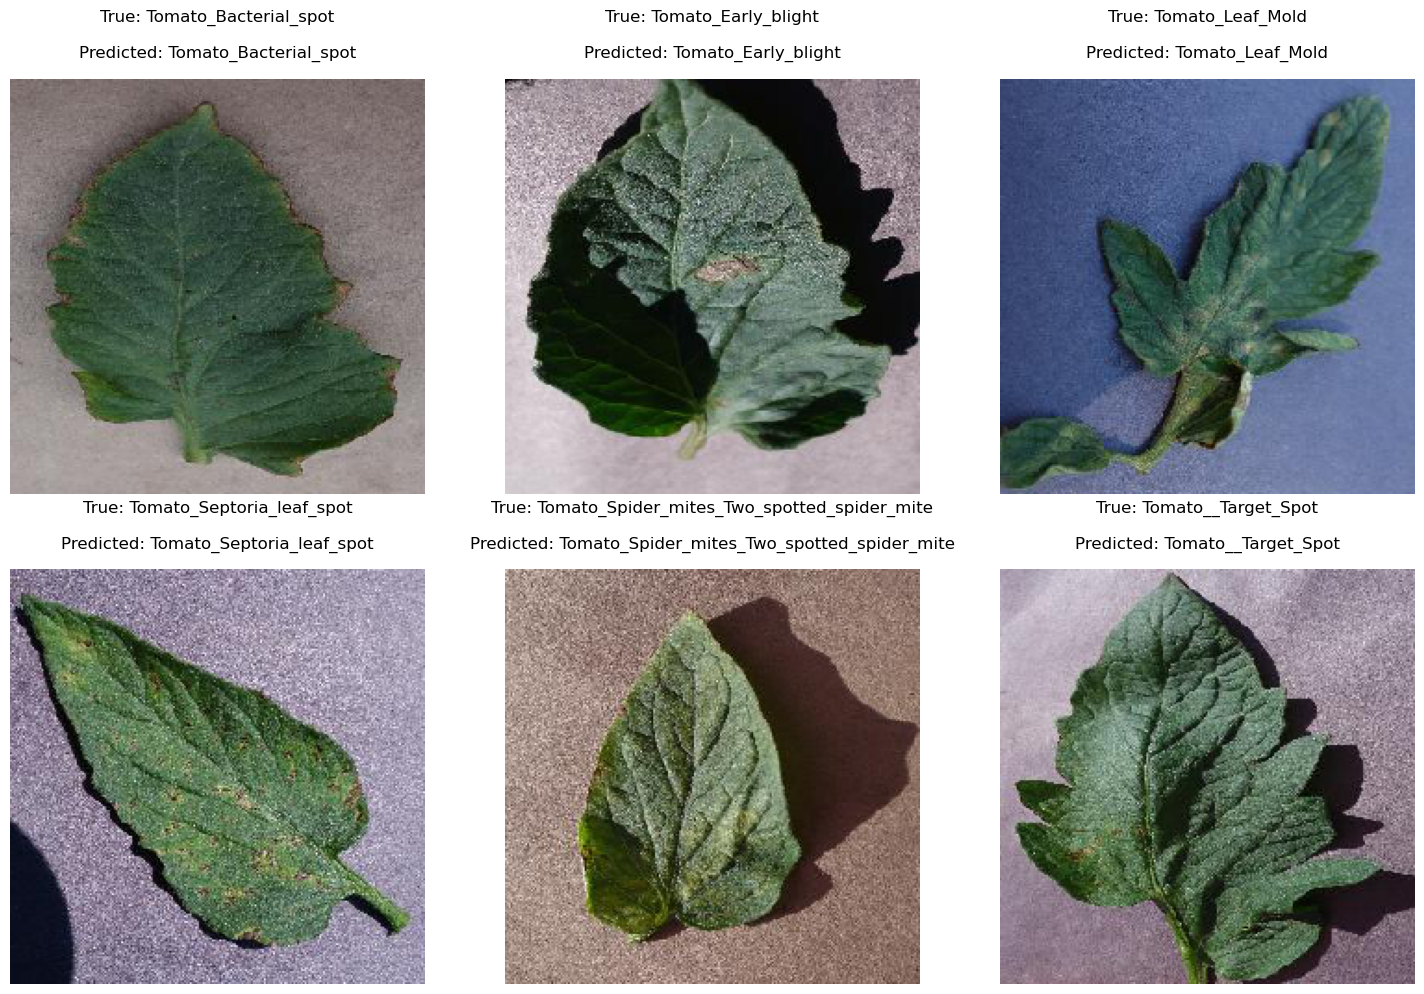

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Load the test dataset
test_set = test_datagen.flow_from_directory(
    r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test",  
    target_size=(224, 224),
    batch_size=16,  
    class_mode='categorical',
    shuffle=False  
)

# Get class names
class_names = list(test_set.class_indices.keys())

# Set the number of images to display
num_images_to_show = 6
num_images_per_row = 3

# Calculate the number of rows needed
num_rows = int(np.ceil(num_images_to_show / num_images_per_row))

# Create subplots
fig, axes = plt.subplots(num_rows, num_images_per_row, figsize=(15, 5*num_rows))  

# Keep track of the classes already displayed
displayed_classes = set()

# Iterate through some images from the test dataset
images_displayed = 0
while images_displayed < num_images_to_show:
    # Get the next image from the test set
    image, true_label = test_set.next()
    true_class = class_names[np.argmax(true_label)]  
    
    # Check if the image belongs to a class that has not been displayed yet
    if true_class not in displayed_classes:
        # Predict the class of the image
        prediction = model.predict(image)
        
        # Check if prediction has the correct shape
        if prediction.shape[1] != len(class_names):
            print("Invalid prediction shape:", prediction.shape)
            continue
        
        # Get the predicted class index
        predicted_class_index = np.argmax(prediction)
        
        # Check if the predicted class index is valid
        if predicted_class_index >= len(class_names):
            print("Invalid predicted class index:", predicted_class_index)
            continue
        
        predicted_class = class_names[predicted_class_index]
        
        # Display the image
        row = images_displayed // num_images_per_row
        col = images_displayed % num_images_per_row
        axes[row, col].imshow(image[0])  
        axes[row, col].axis('off')
        axes[row, col].set_title(f"True: {true_class}\n\nPredicted: {predicted_class}", pad=15)
        
        # Add the true class to the set of displayed classes
        displayed_classes.add(true_class)
        images_displayed += 1

# Adjust layout
plt.tight_layout()
plt.show()

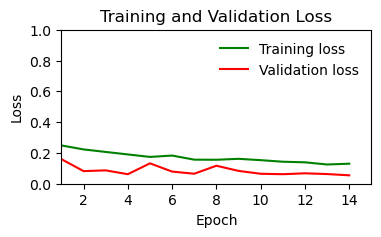

In [39]:
from keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Access loss history
train_losses = history.history['loss']
val_losses = history.history['val_loss']

# Plot the training and validation losses
plt.figure(figsize=(4, 2))  # Adjust the figure size as needed
plt.plot(train_losses, label='Training loss', color='green')
plt.plot(val_losses, label='Validation loss', color='red')
plt.legend(frameon=False)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.ylim(0, 1)  
plt.xlim(1, 15)
plt.show()

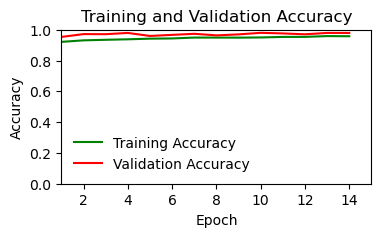

In [40]:
from keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Access accuracy history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracies
plt.figure(figsize=(4, 2))  # Adjust the figure size as needed
plt.plot(train_accuracy, label='Training Accuracy', color='green')
plt.plot(val_accuracy, label='Validation Accuracy', color='red')
plt.legend(frameon=False)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylim(0, 1) 
plt.xlim(1, 15)
plt.show()

In [51]:
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load the trained model
model = load_model("AlexNetmodel.h5")

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)  # You can apply other preprocessing if needed

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Generate predictions for the test set
predictions = model.predict(test_generator, steps=len(test_generator))
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels and class names
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_classes, target_names=class_names))


Found 3211 images belonging to 10 classes.
201/201 [==============================] - 389s 1s/step
Classification Report:
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      0.97      0.98       427
                        Tomato_Early_blight       0.92      0.97      0.94       200
                         Tomato_Late_blight       0.99      0.96      0.98       383
                           Tomato_Leaf_Mold       0.99      0.99      0.99       191
                  Tomato_Septoria_leaf_spot       0.99      0.99      0.99       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.97      0.97       336
                        Tomato__Target_Spot       0.95      0.95      0.95       282
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.99      0.99       643
                Tomato__Tomato_mosaic_virus       0.94      1.00      0.97        75
                           

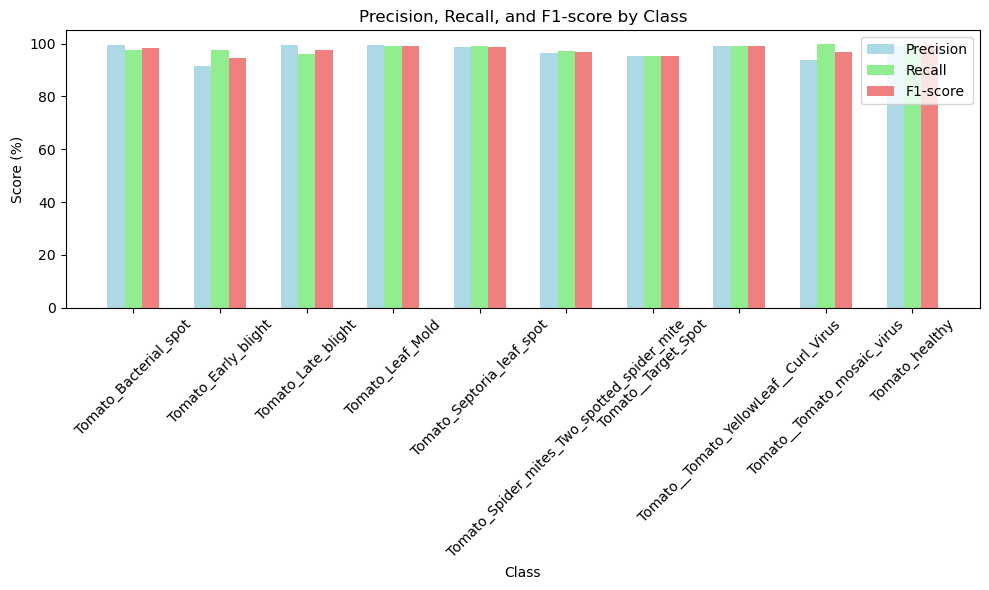

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns

# Get the classification report
report = classification_report(true_labels, predicted_classes, target_names=class_names, output_dict=True)

# Extract precision, recall, and F1-score for each class and multiply them by 100
precision = [report[label]['precision'] * 100 for label in class_names]
recall = [report[label]['recall'] * 100 for label in class_names]
f1_score = [report[label]['f1-score'] * 100 for label in class_names]

# Number of classes
num_classes = len(class_names)

# Plotting
plt.figure(figsize=(10, 6))

bar_width = 0.2
index = np.arange(num_classes)

plt.bar(index, precision, bar_width, label='Precision', color='lightblue')
plt.bar(index + bar_width, recall, bar_width, label='Recall', color='lightgreen')
plt.bar(index + 2 * bar_width, f1_score, bar_width, label='F1-score', color='lightcoral')

plt.xlabel('Class')
plt.ylabel('Score (%)')  # Update ylabel to reflect percentages
plt.title('Precision, Recall, and F1-score by Class')
plt.xticks(index + bar_width, class_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Found 3211 images belonging to 10 classes.
201/201 [==============================] - 99s 459ms/step
Confusion Matrix:
[[416   3   0   0   0   0   4   4   0   0]
 [  2 195   1   0   1   0   0   1   0   0]
 [  0   9 368   1   2   0   2   0   0   1]
 [  0   0   1 189   0   0   0   0   1   0]
 [  0   2   0   0 352   0   1   0   0   0]
 [  0   0   0   0   0 327   5   0   4   0]
 [  0   4   0   0   2   5 269   0   0   2]
 [  0   0   0   0   0   7   0 636   0   0]
 [  0   0   0   0   0   0   0   0  75   0]
 [  0   0   0   0   0   0   1   0   0 318]]


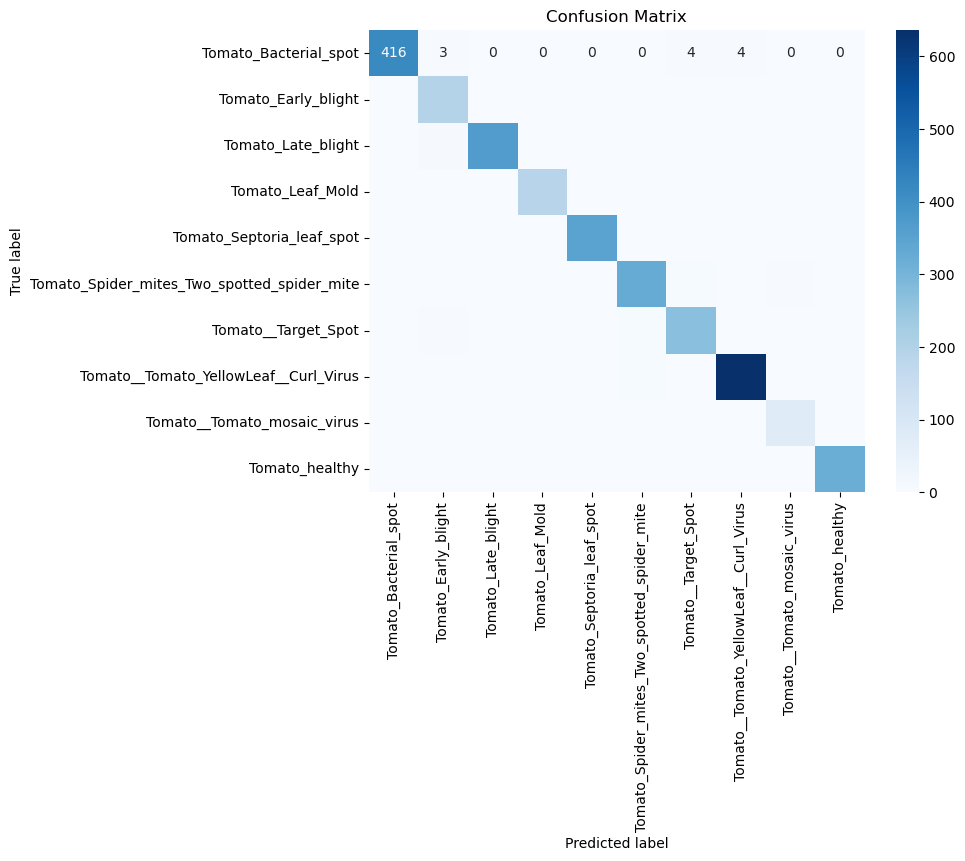

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# Load the model
model_path = r"C:\Users\Chourouk\Desktop\AlexNetunb\AlexNetmodel.h5"
model = load_model(model_path)

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)  # You can apply other preprocessing if needed

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Get predictions
pred_labels = np.argmax(model.predict(test_generator), axis=1)
true_labels = test_generator.classes

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()


Found 3211 images belonging to 10 classes.
201/201 [==============================] - 54s 265ms/step


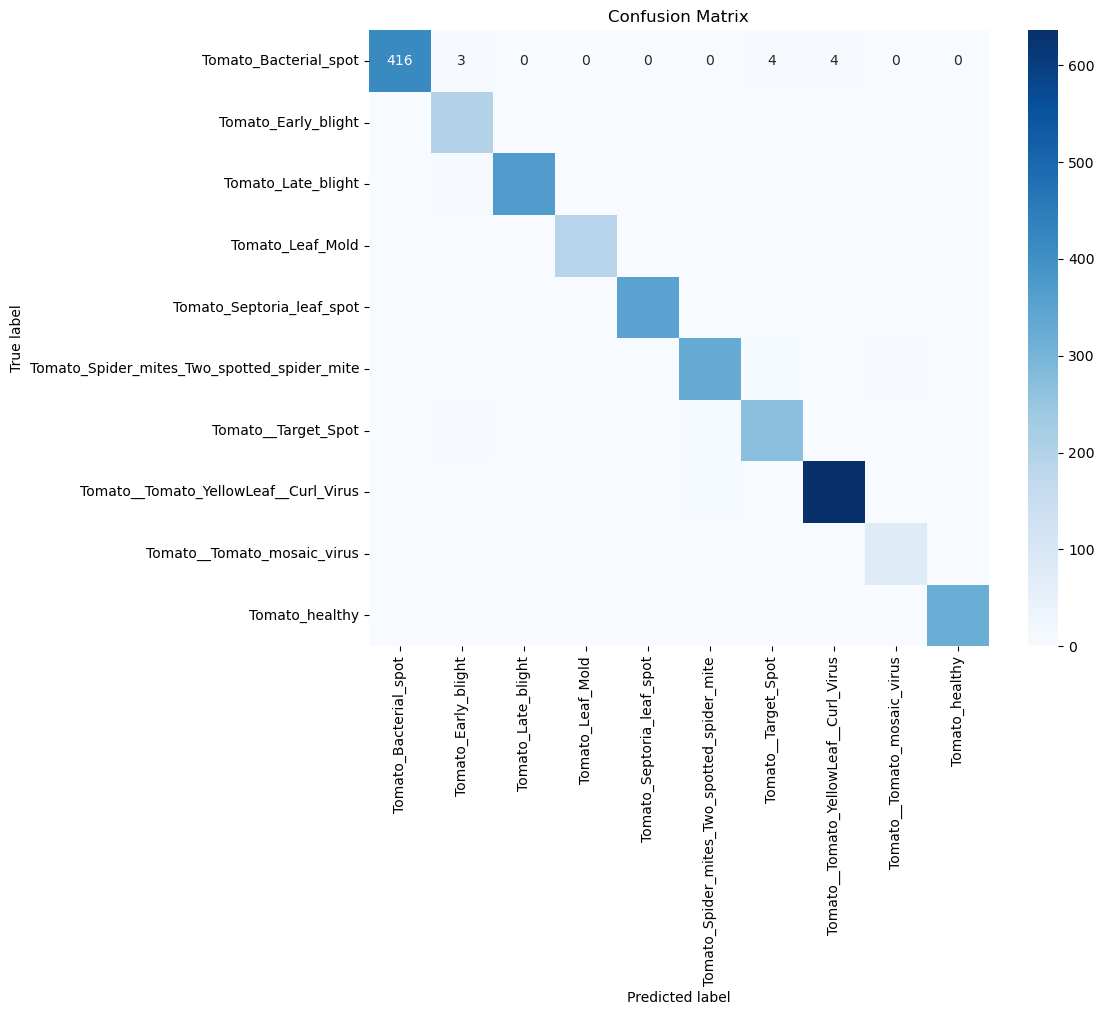

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

# Load the model
model_path = r"C:\Users\Chourouk\Desktop\AlexNetunb\AlexNetmodel.h5"
model = load_model(model_path)

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)  # You can apply other preprocessing if needed

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Get predictions
pred_labels = np.argmax(model.predict(test_generator), axis=1)
true_labels = test_generator.classes

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()

Found 3211 images belonging to 10 classes.
201/201 [==============================] - 25s 123ms/step


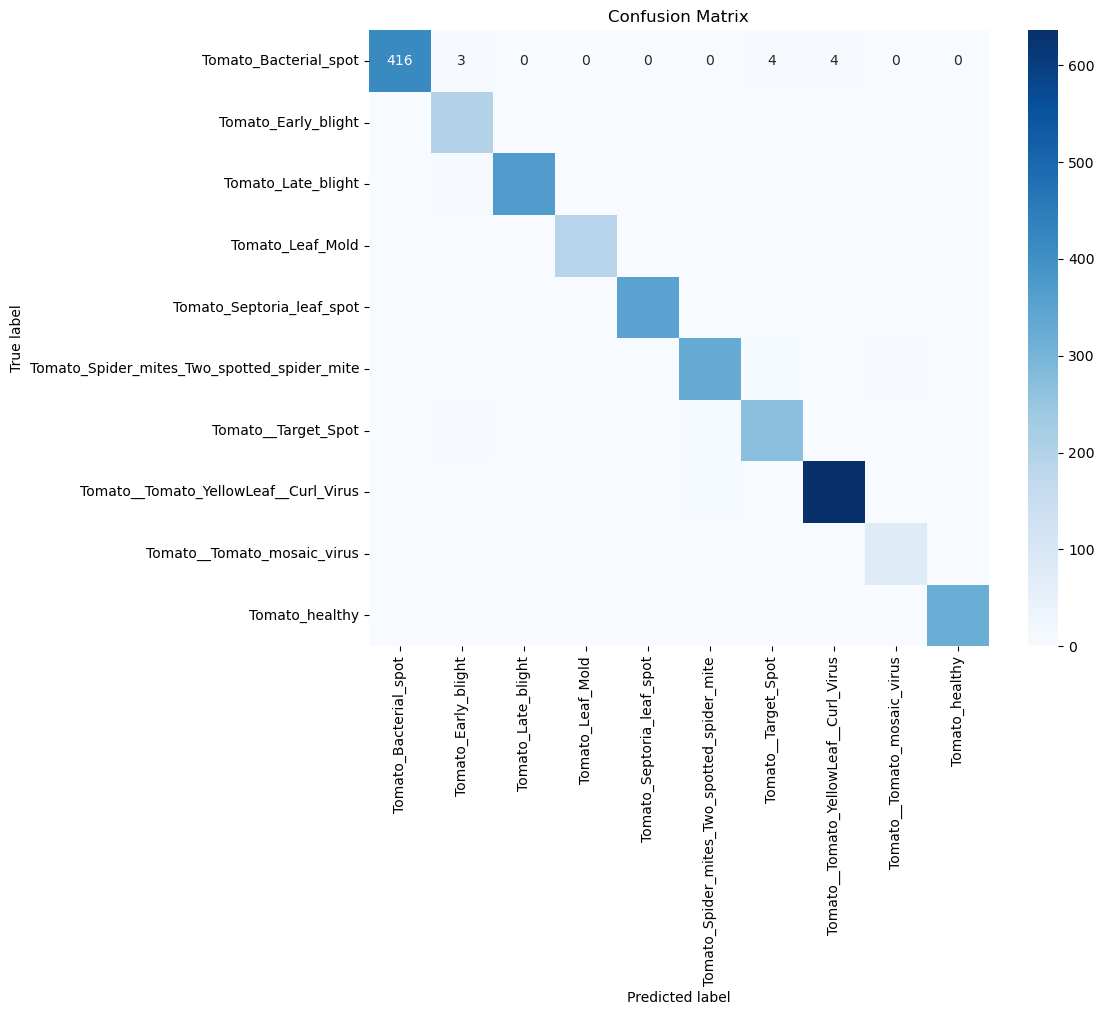

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

# Load the model
model_path = r"C:\Users\Chourouk\Desktop\AlexNetunb\AlexNetmodel.h5"
model = load_model(model_path)

# Define the path to your test dataset directory
test_dir = r"C:\Users\Chourouk\Desktop\AlexNetunb\dataset\test"

# Create an ImageDataGenerator for the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)  # You can apply other preprocessing if needed

# Load the test dataset from the directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Adjust the target size as needed
    batch_size=16,           # Adjust the batch size as needed
    class_mode='categorical',  # Assuming you have categorical labels
    shuffle=False             # No need to shuffle for evaluation
)

# Get predictions
pred_labels = np.argmax(model.predict(test_generator), axis=1)
true_labels = test_generator.classes

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Extract class labels
class_labels = list(test_generator.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()
